### En primer lugar, deberemos de descargar las librerias necesarias para realizar la tarea

In [1]:
# Celda 1: instalación
%pip install -q transformers torch torchvision easyocr opencv-python matplotlib pandas ultralytics huggingface_hub edge-tts



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Ahora vamos a empezar con la práctica

In [2]:
import cv2
import torch
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

# Descargar modelo desde Hugging Face (se cachea automáticamente)
model_path = hf_hub_download(
    repo_id="morsetechlab/yolov11-license-plate-detection",
    filename="license-plate-finetune-v1s.pt"  # n=ligero, cambia a v1s/v1m/v1l/v1x para mayor precisión
)

# Cargar con ultralytics
model = YOLO(model_path)

# EasyOCR
reader = easyocr.Reader(['es'], gpu=torch.cuda.is_available())

In [3]:
import csv
import os
from datetime import datetime
import re

# Crear el archivo y las cabeceras si no existe
csv_filename = 'matriculas_detectadas.csv'
if not os.path.exists(csv_filename):
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Fecha_Hora', 'Matricula', 'Archivo_Origen'])

In [4]:
def detectar_y_leer(imagen_path):
    # 1. Cargar imagen
    image = cv2.imread(imagen_path)
    
    # 2. Detectar matriculas, utilicé 0.5 ya que es la confianza mínima para considerar una detección válida.
    results = model.predict(image, conf=0.5, verbose=False)[0]
    
    # Recorrer TODAS las detecciones
    for box in results.boxes:

        # Obtener coordenadas en formato entero
        coordenadas = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1, x2, y2 = coordenadas
        
        # 3. Recortar esta matricula (con margen interior para evitar bordes)
        margin_x = int((x2 - x1) * 0.08)
        margin_y = int((y2 - y1) * 0.05)
        placa = image[y1+margin_y : y2-margin_y, x1+margin_x : x2-margin_x]
        
        if placa.size == 0: 
            continue
        
        # 4. Preprocesar para leer texto
        gray = cv2.cvtColor(placa, cv2.COLOR_BGR2GRAY)
        
        # Escalar x3 si la matrícula es pequeña, o x2 si es normal
        escala = 3 if (x2 - x1) < 100 else 2
        gray = cv2.resize(gray, None, fx=escala, fy=escala, interpolation=cv2.INTER_CUBIC)
        
        # Aplicar threshold adaptativo para mejorar contraste
        #gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

        # 5. Leer texto (EasyOCR)
        lectura = reader.readtext(gray, allowlist='BCDFGHJKLMNPQRSTVWXYZ0123456789', paragraph=True)
        
        texto = ""
        if len(lectura) > 0:
            texto = lectura[0][1].upper().replace(" ", "")

        # Formateado de la matrícula: 4 dígitos + 3 letras (sin vocales ni Ñ)
            patron = r'^[0-9]{4}[BCDFGHJKLMNPRSTVWXYZ]{3}$'
            es_valida = bool(re.match(patron, texto))
            color = (0, 255, 0) if es_valida else (0, 0, 255)  # Verde válida / Rojo inválida
        else:
            color = (0, 165, 255)  # Naranja si no detecta nada

        # Guardar en CSV si es válida
        if texto and es_valida:
            fecha_hora = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            with open(csv_filename, mode="a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([fecha_hora, texto, os.path.basename(imagen_path)])

        # Guardar en .txt las matriculas leidas, en orden para generar audio después
        if texto:
            with open("matriculas_detectadas.txt", mode="a", encoding="utf-8") as f:
                f.write(f"{texto}\n")

        # 6. Dibujar resultado
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, texto, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        
    return image

Procesado: 91043770-f905-5f16-99fb-20ae8c21e3f0.jpg | Guardado en: resultados_img/res_91043770-f905-5f16-99fb-20ae8c21e3f0.jpg


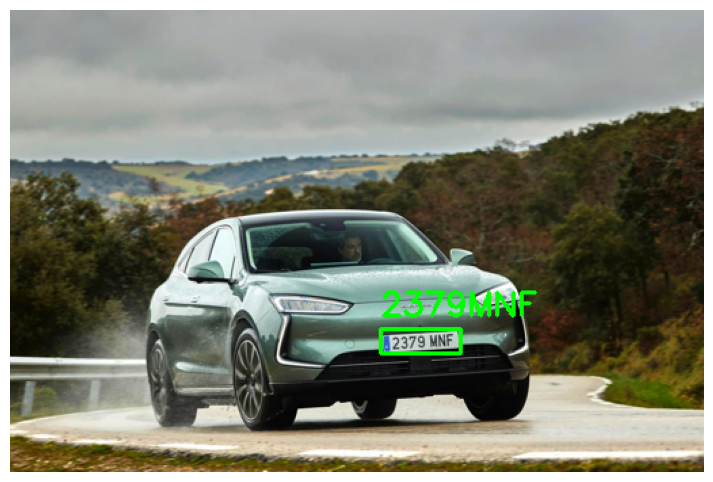

Procesado: atasco-kYlG-U901049533897azG-1248x770Ideal.jpg | Guardado en: resultados_img/res_atasco-kYlG-U901049533897azG-1248x770Ideal.jpg


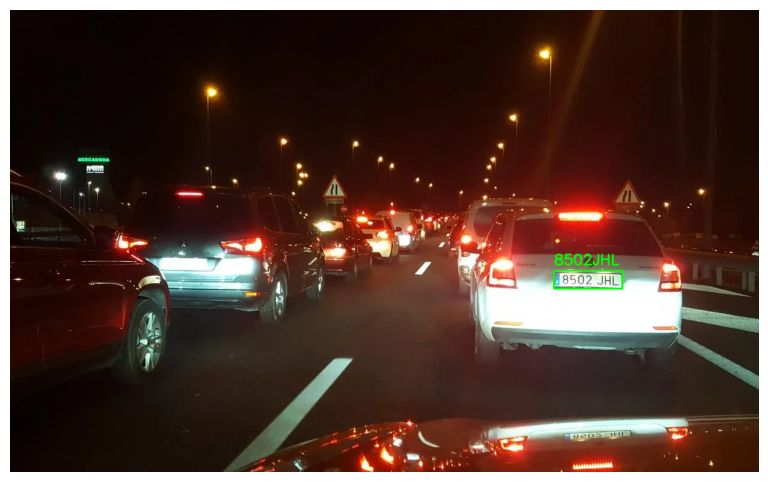

Procesado: 450_1000.jpg | Guardado en: resultados_img/res_450_1000.jpg


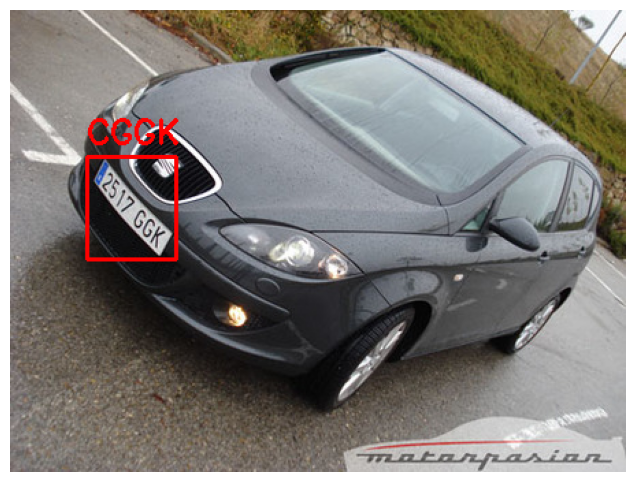

Procesado: Matrículas-de-coche-curiosas.jpg | Guardado en: resultados_img/res_Matrículas-de-coche-curiosas.jpg


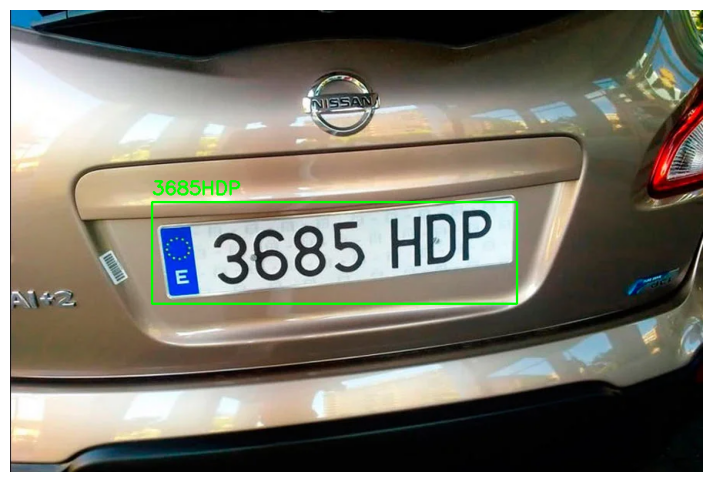

Procesado: Captura de pantalla 2026-02-25 155228.jpg | Guardado en: resultados_img/res_Captura de pantalla 2026-02-25 155228.jpg


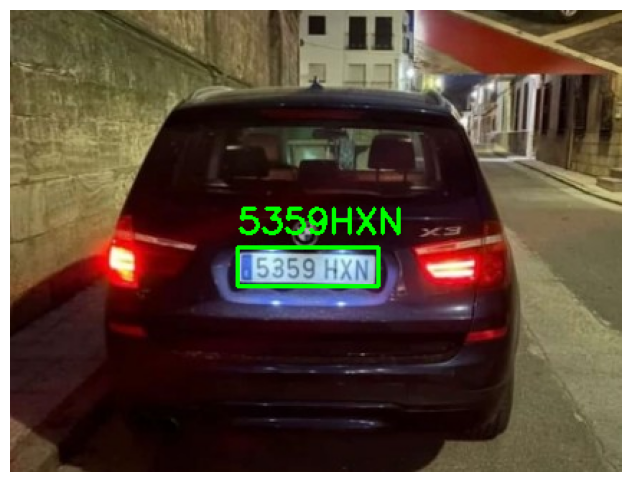

In [5]:
import matplotlib.pyplot as plt

# Crear carpeta de fotos
output_folder = "resultados_img"
os.makedirs(output_folder, exist_ok=True)

folder = "fotos"
if os.path.exists(folder):
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            
            # Procesar
            img_resultado = detectar_y_leer(path)
            
            if img_resultado is not None:
                # 1. Guardar imagen en disco
                save_path = os.path.join(output_folder, f"res_{filename}")
                cv2.imwrite(save_path, img_resultado)
                
                # 2. Mostrar resultados
                print(f"Procesado: {filename} | Guardado en: {save_path}")
                plt.figure(figsize=(10, 6))
                plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()


### ¿Qué pasa si la foto sale poco iluminada o inclinada?

- Cuando la matrícula esta inclinada, el modelo YOLO sigue siendo capaz de detectar la caja delimitadora (bounding box) de la matrícula con alta confianza, ya que las características del objeto siguen presentes. Sin embargo, EasyOCR pierde mucha precisión al intentar extraer el texto. Al procesar un recorte rectangular de un objeto inclinado, las letras y números se solapan en el eje horizontal. La solución ideal sería aplicar una transformación de perspectiva (*warp perspective*) con OpenCV antes de pasar el recorte al OCR.

- En condiciones de baja luminosidad, el contraste entre el fondo reflectante blanco y los caracteres negros disminuye drásticamente. Al aplicar el umbral (*thresholding*) requerido en la Fase 2, la imagen tiende a saturarse hacia el negro, fusionando el texto con el fondo y haciendo imposible la lectura para EasyOCR. Para mitigar este problema, sería necesario aplicar algoritmos de ecualización de histograma adaptativo (como CLAHE) antes de la binarización para realzar el contraste localmente.

In [7]:
# Generar audio con las matrículas detectadas del .txt
import asyncio
import edge_tts

# Seleccionando modelo
voz = "es-ES-AlvaroNeural"   # también puedes usar es-ES

# Cargando texto desde un archivo
with open("matriculas_detectadas.txt", "r", encoding="utf-8") as f:
    texto = f.read()

async def main():
    communicate = edge_tts.Communicate(texto, voz)
    await communicate.save("matriculas.mp3")

await main()
print("Audio guardado en matriculas.mp3")

Audio guardado en matriculas.mp3
